In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("pkgs_datasets_final_name-title.csv")

# Preview
df.head()

,Package,dataset_title
0,A3,Ecosystem Multifunctionality
1,A3,Boston Housing Prices
2,ABC.RAP,test dataset of 450k DNA methylation
3,ABC.RAP,annotation file for the 450k probes
4,ABC.RAP,450k DNA methylation non specific probes


In [4]:

df.head()

,Package,dataset_title
0,A3,Ecosystem Multifunctionality
1,A3,Boston Housing Prices
2,ABC.RAP,test dataset of 450k DNA methylation
3,ABC.RAP,annotation file for the 450k probes
4,ABC.RAP,450k DNA methylation non specific probes


In [5]:

print(df.columns)

Index(['Package', 'dataset_title'], dtype='str')


In [7]:
df.shape
df.head()

,Package,dataset_title
0,A3,Ecosystem Multifunctionality
1,A3,Boston Housing Prices
2,ABC.RAP,test dataset of 450k DNA methylation
3,ABC.RAP,annotation file for the 450k probes
4,ABC.RAP,450k DNA methylation non specific probes


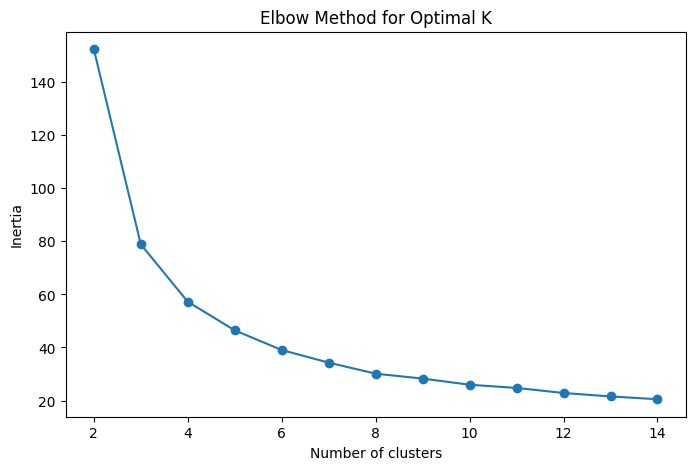

In [9]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

data = load_iris()
X = data.data

inertia = []
K_range = range(2, 15)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [11]:
print(type(X))

<class 'numpy.ndarray'>


In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

corpus = [
    "dog bites man",
    "man bites dog",
    "dog eats food",
    "cat plays with yarn",
    "cat eats fish"
]

k = 2  # number of clusters

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(k):
    print(f"\nCluster {i}:")
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_terms))


Cluster 0:
dog, man, bites, food, eats, yarn, with, plays, fish, cat

Cluster 1:
cat, yarn, with, plays, fish, eats, man, food, dog, bites


In [15]:
df.to_csv("clustered_results.csv", index=False)